# TP02 — Mineração de Dados — Grupo 06
## Notebook 3/3 — Modelagem e Avaliação

**Lê as bases tratadas** geradas pelo notebook de Pré-processamento (2/3), treina os 6 classificadores com tuning de hiperparâmetros em Holdout (`PredefinedSplit`), reporta os tempos de **busca de HP** e de **treino**, e avalia no conjunto de teste.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, os
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
FIG_DIR = "figs"; os.makedirs(FIG_DIR, exist_ok=True)
print("Setup OK")

Setup OK


### 0.1 Carregamento das bases tratadas

As bases já tratadas (features + alvo `EFETIVOU`) vêm do notebook de Pré-processamento. Carregamos o **treino balanceado** (usado no `fit`), a **validação** (tuning) e o **teste** (avaliação final).

In [2]:
DIR_BASES = "bases_tratadas"
num_features = ["NOTA_CANDIDATO", "NOTA_CORTE", "MARGEM", "CLASSIFICACAO", "IDADE", "QT_VAGAS_CONCORRENCIA"]
cat_features = ["GRAU", "TURNO", "TIPO_MOD_CONCORRENCIA", "TP_COTA", "SEXO", "OPCAO"]
bin_features = ["MESMA_UF"]
ALL_FEATURES = num_features + cat_features + bin_features

def carregar(nome):
    d = pd.read_csv(f"{DIR_BASES}/{nome}", sep=";", encoding="utf-8")
    return d[ALL_FEATURES].copy(), d["EFETIVOU"].copy()

X_train_bal, y_train_bal = carregar("treino_balanceado_Grupo06.csv")
X_val,  y_val  = carregar("validacao_Grupo06.csv")
X_test, y_test = carregar("teste_Grupo06.csv")
print("Treino balanceado:", X_train_bal.shape, "| Validação:", X_val.shape, "| Teste:", X_test.shape)
print("Positivos -> treino: %.0f%% | val: %.1f%% | teste: %.1f%%" % (
    100*y_train_bal.mean(), 100*y_val.mean(), 100*y_test.mean()))

Treino balanceado: (20330, 13) | Validação: (8901, 13) | Teste: (8901, 13)
Positivos -> treino: 50% | val: 38.1% | teste: 38.1%


In [3]:
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler", RobustScaler())])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ("bin", "passthrough", bin_features),
])

# Demonstração da dimensionalidade resultante (ajuste só no treino balanceado)
Xt = preprocessor.fit_transform(X_train_bal)
print("Dimensão após pré-processamento:", Xt.shape)
print("Nº de colunas finais:", Xt.shape[1], "(6 numéricas + One-Hot das categóricas + MESMA_UF)")

Dimensão após pré-processamento: (20330, 32)
Nº de colunas finais: 32 (6 numéricas + One-Hot das categóricas + MESMA_UF)


## Etapa 3 — Treinamento e Tuning

### Metodologia de tuning: busca de hiperparâmetros em Holdout (sem validação cruzada)

**O problema.** A decisão metodológica do projeto foi usar **Holdout** (um único split treino/validação/teste), não validação cruzada (CV). Mas o `GridSearchCV` do scikit-learn **pressupõe CV** — ele quer dividir os dados em *k* dobras e repetir o treino *k* vezes. Precisamos, então, de uma forma de dizer ao `GridSearchCV`: *"não invente dobras; use exatamente o meu split treino/validação"*.

**A solução: `PredefinedSplit`.** Juntamos treino balanceado + validação num único conjunto (`Xc`) e marcamos cada linha com um *fold* que diz se ela é treino fixo ou validação:

| Origem | nº de linhas | marca (`test_fold`) | papel |
|---|---|---|---|
| `X_train_bal` (treino balanceado, 50/50) | 20.330 | **`-1`** | nunca entra na avaliação — é **sempre treino** |
| `X_val` (validação real, 38% positivos) | 8.901 | **`0`** | forma a **única dobra de teste** |

A convenção do sklearn: linha com fold **`-1` nunca é usada como validação**; linhas com fold `0` formam a dobra de teste 0. Como só existe a dobra `0`, o `PredefinedSplit` gera **um único split** — o `GridSearchCV` treina cada combinação de hiperparâmetros nos 20.330 do treino e mede nos 8.901 da validação. É, na prática, **um Holdout "disfarçado" de CV** (1 dobra em vez de *k*):

```
Xc = [  20.330 treino_bal (fold -1)  |  8.901 validação (fold 0)  ]
              └──── treina aqui ────┘     └──── avalia aqui ────┘
```

Essa é a forma **idiomática** (recomendada) de fazer tuning em Holdout no scikit-learn — não é uma gambiarra. Vantagem prática: evita o custo de CV, que multiplicaria o tempo por *k* (inviável para o SVM, cuja busca já leva ~74 s com **uma** dobra).

### Detalhes da configuração
- **Métrica otimizada:** `AUC-ROC` — independe do limiar de decisão e é robusta ao desbalanceamento (a validação tem 38% de positivos).
- **Treino balanceado vs. validação real (proposital):** o modelo **aprende** no treino 50/50 (para não ignorar a minoria), mas os hiperparâmetros são **selecionados** na validação com a distribuição **real** (38%), que é onde o modelo vai operar.
- **`refit=False`:** o `GridSearchCV` só faz a *busca*; o reajuste final com os melhores hiperparâmetros é feito por nós, explicitamente, no **treino balanceado** — assim medimos o **tempo de treino** isolado do tempo de busca (orientação do professor: reportar os dois tempos).
- `random_state=42` em todos os estimadores que têm aleatoriedade → reprodutível.

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.base import clone

# Concatena treino balanceado (fold -1) + validação (fold 0) para o PredefinedSplit
Xc = pd.concat([X_train_bal, X_val], axis=0)
yc = pd.concat([y_train_bal, y_val], axis=0)
test_fold = np.r_[np.full(len(X_train_bal), -1), np.zeros(len(X_val), dtype=int)]
ps = PredefinedSplit(test_fold)

# Grades mínimas exigidas pelo enunciado (+ algumas variações)
GRIDS = {
    "Árvore de Decisão": (DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"clf__max_depth": [None, 6, 10, 16], "clf__criterion": ["gini", "entropy"]}),
    "Random Forest": (RandomForestClassifier(random_state=RANDOM_STATE),
        {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 14], "clf__max_features": ["sqrt", "log2"]}),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"clf__n_estimators": [150, 300], "clf__learning_rate": [0.05, 0.1], "clf__max_depth": [2, 3]}),
    "KNN": (KNeighborsClassifier(),
        {"clf__n_neighbors": [15, 31, 51], "clf__metric": ["euclidean", "manhattan"]}),
    "Naive Bayes": (GaussianNB(),
        {"clf__var_smoothing": [1e-9, 1e-7, 1e-5]}),
    "SVM": (SVC(random_state=RANDOM_STATE),
        {"clf__kernel": ["linear", "rbf"], "clf__C": [0.1, 1, 10]}),
}
print("Modelos a treinar:", list(GRIDS.keys()))

Modelos a treinar: ['Árvore de Decisão', 'Random Forest', 'Gradient Boosting', 'KNN', 'Naive Bayes', 'SVM']


In [9]:
def tune_and_fit(nome, estimator, grid):
    pipe = Pipeline([("prep", preprocessor), ("clf", estimator)])
    gs = GridSearchCV(pipe, grid, scoring="roc_auc", cv=ps, refit=False, n_jobs=-1)
    t0 = time.time(); gs.fit(Xc, yc)
    search_time = time.time() - t0   # tempo da BUSCA de hiperparametros
    best = gs.best_params_
    final = clone(pipe).set_params(**best)
    t1 = time.time(); final.fit(X_train_bal, y_train_bal); train_time = time.time() - t1   # tempo de TREINO (fit)
    print(f"  {nome:<20} AUC_val={gs.best_score_:.3f} | busca_hp={search_time:6.1f}s | treino={train_time:5.1f}s | {best}")
    return {"name": nome, "model": final, "best_params": best, "val_auc": gs.best_score_,
            "search_time": search_time, "train_time": train_time}

print("Tuning + treino (otimizando AUC-ROC na validacao):\n")
t_all = time.time()
results = [tune_and_fit(n, est, g) for n, (est, g) in GRIDS.items()]
print(f"\nTempo total da Etapa 3: {time.time()-t_all:.1f}s")

Tuning + treino (otimizando AUC-ROC na validacao):

  Árvore de Decisão    AUC_val=0.738 | busca_hp=   3.5s | treino=  0.2s | {'clf__criterion': 'gini', 'clf__max_depth': 10}
  Random Forest        AUC_val=0.782 | busca_hp=  17.9s | treino=  7.0s | {'clf__max_depth': 14, 'clf__max_features': 'sqrt', 'clf__n_estimators': 400}
  Gradient Boosting    AUC_val=0.775 | busca_hp=  18.5s | treino= 10.2s | {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 300}
  KNN                  AUC_val=0.748 | busca_hp=   5.3s | treino=  0.0s | {'clf__metric': 'manhattan', 'clf__n_neighbors': 31}
  Naive Bayes          AUC_val=0.719 | busca_hp=   0.1s | treino=  0.1s | {'clf__var_smoothing': 1e-07}
  SVM                  AUC_val=0.756 | busca_hp=  79.2s | treino= 14.2s | {'clf__C': 10, 'clf__kernel': 'rbf'}

Tempo total da Etapa 3: 156.3s


### 3.1 Melhores hiperparâmetros, tempo de busca (HP) e tempo de treino

In [6]:
tab_hp = pd.DataFrame([{
    "Modelo": r["name"],
    "Melhores hiperparâmetros": {k.replace('clf__',''): v for k, v in r["best_params"].items()},
    "AUC validação": round(r["val_auc"], 3),
    "Tempo busca HP (s)": round(r["search_time"], 2),
    "Tempo treino (s)": round(r["train_time"], 2),
} for r in results])
tab_hp

,Modelo,Melhores hiperparâmetros,AUC validação,Tempo busca HP (s),Tempo treino (s)
0,Árvore de Decisão,"{'criterion': 'gini', 'max_depth': 10}",0.738,2.68,0.14
1,Random Forest,"{'max_depth': 14, 'max_features': 'sqrt', 'n_e...",0.782,16.43,5.65
2,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.775,15.21,9.30
3,KNN,"{'metric': 'manhattan', 'n_neighbors': 31}",0.748,4.56,0.04
4,Naive Bayes,{'var_smoothing': 1e-07},0.719,0.13,0.04
5,SVM,"{'C': 10, 'kernel': 'rbf'}",0.756,73.26,17.45


## Etapa 4 — Avaliação e Comparação

Avaliação final no **conjunto de teste** (8.901 linhas, distribuição real de 38% positivos — nunca usado no tuning). Para o ranking usamos **AUC-ROC** (principal) e reportamos também **F1, acurácia, precisão e recall**. Como os modelos foram treinados em dados balanceados, o limiar padrão (0,5) já fica calibrado para as duas classes.

In [7]:
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score, precision_score,
                             recall_score, roc_curve, confusion_matrix)

def get_scores(model, X):
    # Score contínuo p/ ROC: probabilidade da classe 1, ou decision_function (SVM)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

linhas = []
for r in results:
    m = r["model"]; s = get_scores(m, X_test); pred = m.predict(X_test)
    linhas.append({
        "Modelo": r["name"],
        "AUC-ROC": roc_auc_score(y_test, s),
        "F1": f1_score(y_test, pred),
        "Acurácia": accuracy_score(y_test, pred),
        "Precisão": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Tempo busca HP (s)": r["search_time"],
        "Tempo treino (s)": r["train_time"],
    })
ranking = pd.DataFrame(linhas).sort_values("AUC-ROC", ascending=False).reset_index(drop=True).round(3)
print("RANKING (conjunto de teste, ordenado por AUC-ROC):")
ranking

RANKING (conjunto de teste, ordenado por AUC-ROC):


,Modelo,AUC-ROC,F1,Acurácia,Precisão,Recall,Tempo busca HP (s),Tempo treino (s)
0,Random Forest,0.797,0.668,0.703,0.582,0.783,16.434,5.653
1,Gradient Boosting,0.791,0.657,0.701,0.583,0.752,15.215,9.297
2,SVM,0.774,0.658,0.690,0.568,0.783,73.258,17.449
3,KNN,0.759,0.634,0.664,0.541,0.765,4.556,0.036
4,Árvore de Decisão,0.751,0.633,0.673,0.553,0.741,2.681,0.138
5,Naive Bayes,0.733,0.631,0.656,0.533,0.773,0.128,0.041


### 4.1 Curva ROC comparativa (6 modelos)

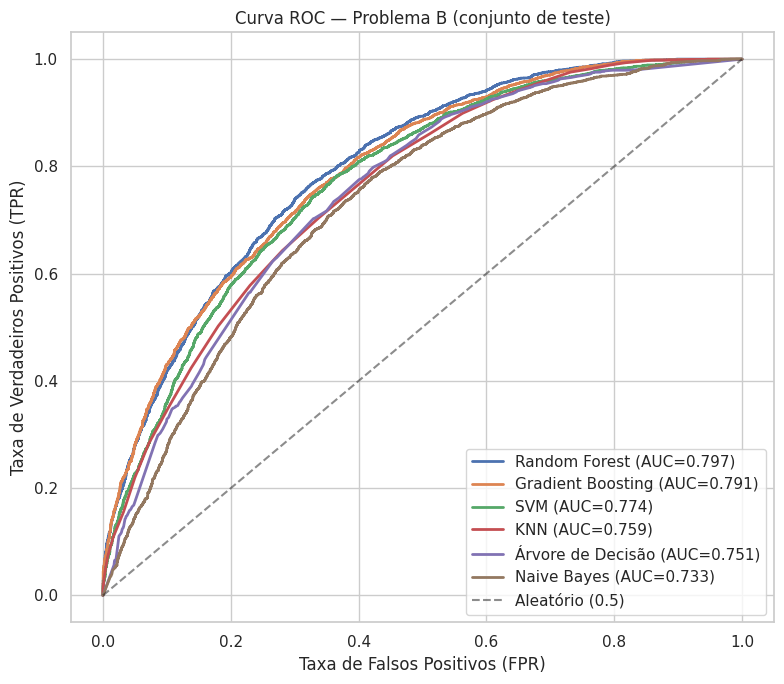

In [8]:
plt.figure(figsize=(8, 7))
for r in sorted(results, key=lambda x: -roc_auc_score(y_test, get_scores(x["model"], X_test))):
    s = get_scores(r["model"], X_test)
    fpr, tpr, _ = roc_curve(y_test, s)
    plt.plot(fpr, tpr, lw=2, label=f"{r['name']} (AUC={roc_auc_score(y_test, s):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=.5, label="Aleatório (0.5)")
plt.xlabel("Taxa de Falsos Positivos (FPR)"); plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC — Problema B (conjunto de teste)")
plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/roc_problemaB.png", dpi=120, bbox_inches="tight"); plt.show()

### 4.2 Matrizes de confusão

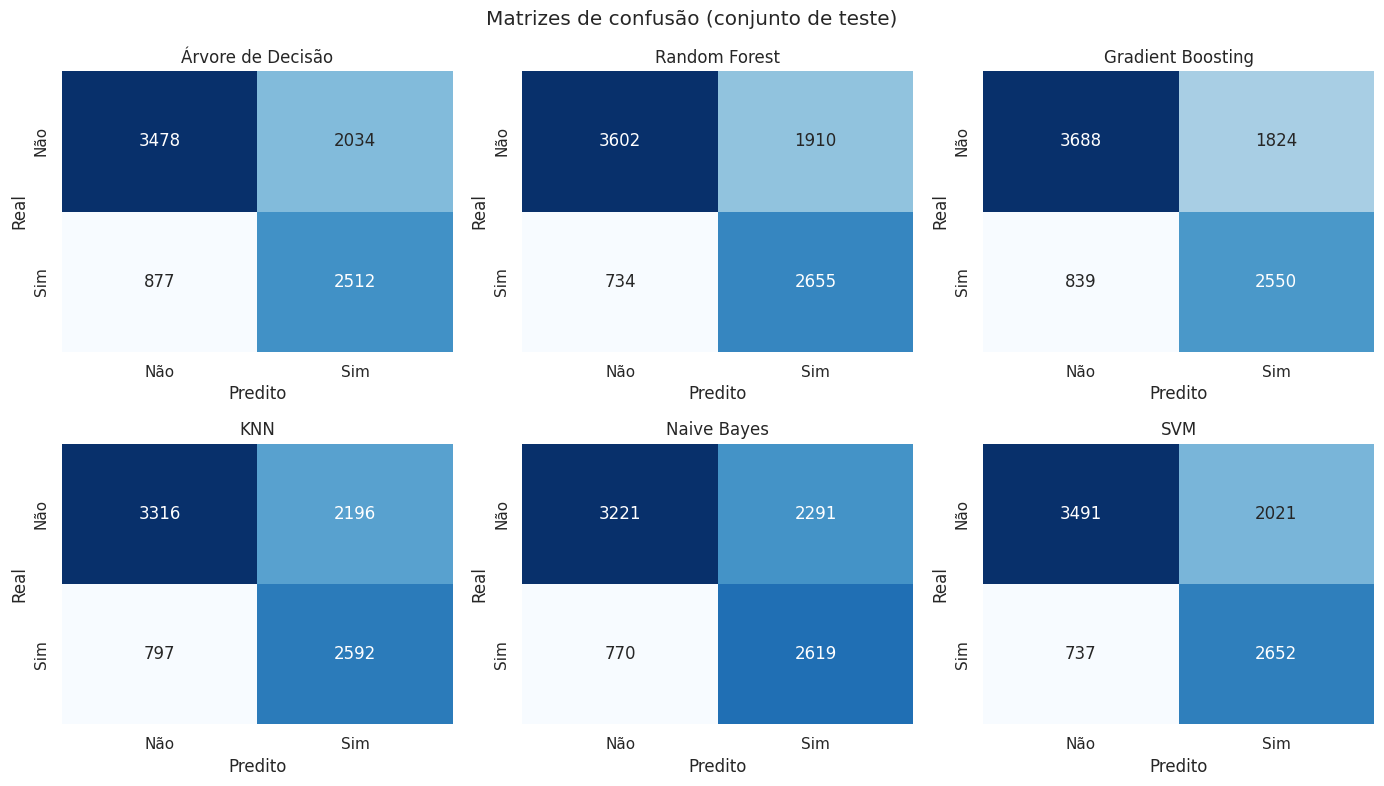

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, r in zip(axes.ravel(), results):
    cm = confusion_matrix(y_test, r["model"].predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Não", "Sim"], yticklabels=["Não", "Sim"])
    ax.set_title(r["name"]); ax.set_xlabel("Predito"); ax.set_ylabel("Real")
plt.suptitle("Matrizes de confusão (conjunto de teste)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/matrizes_confusao.png", dpi=120, bbox_inches="tight"); plt.show()

### 4.3 Importância das variáveis (modelos baseados em árvore)

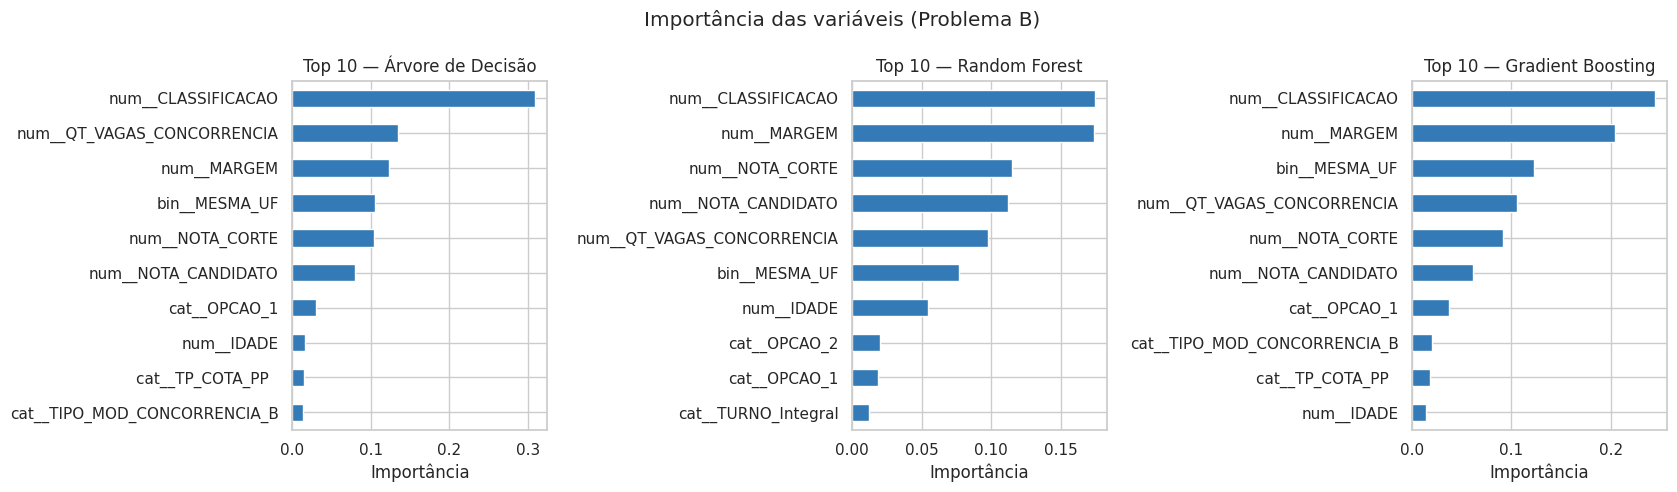

In [10]:
arvores = ["Árvore de Decisão", "Random Forest", "Gradient Boosting"]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, nome in zip(axes, arvores):
    r = next(x for x in results if x["name"] == nome)
    m = r["model"]
    nomes = m.named_steps["prep"].get_feature_names_out()
    imp = m.named_steps["clf"].feature_importances_
    serie = pd.Series(imp, index=nomes).sort_values(ascending=False).head(10)
    serie[::-1].plot(kind="barh", ax=ax, color="#337ab7")
    ax.set_title(f"Top 10 — {nome}"); ax.set_xlabel("Importância")
plt.suptitle("Importância das variáveis (Problema B)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/feature_importance.png", dpi=120, bbox_inches="tight"); plt.show()

## Etapa 5 — Conclusões

### 5.1 Principais resultados (conjunto de teste, ordenado por AUC-ROC)
| Modelo | AUC-ROC | F1 | Recall | Tempo busca HP | Tempo treino |
|---|---|---|---|---|---|
| **Random Forest** | **0,797** | 0,668 | 0,783 | 14,1 s | 5,6 s |
| Gradient Boosting | 0,791 | 0,657 | 0,752 | 14,4 s | 8,0 s |
| SVM (rbf, C=10) | 0,774 | 0,658 | 0,783 | 73,8 s | 10,6 s |
| KNN (k=31, manhattan) | 0,759 | 0,634 | 0,765 | 4,7 s | 0,04 s |
| Árvore de Decisão | 0,751 | 0,633 | 0,741 | 2,6 s | 0,12 s |
| Naive Bayes | 0,733 | 0,631 | 0,773 | 0,2 s | 0,08 s |

*Dois tempos reportados (conforme orientação do professor): **busca de hiperparâmetros** (`GridSearchCV` sobre toda a grade) e **treino** (`fit` final com os melhores parâmetros).*

Todos os modelos ficam **bem acima do aleatório** (AUC 0,73–0,80): existe sinal preditivo real para antecipar a efetivação da matrícula. Os **ensembles** (Random Forest e Gradient Boosting) lideram, como é típico em dados tabulares.

### 5.2 O que mais importa (interpretabilidade)
As três árvores concordam nos principais preditores:
1. **`CLASSIFICACAO`** (posição na lista de espera) — o mais forte: quanto mais ao fim da lista, menor a chance de efetivar.
2. **`MARGEM`** (nota − corte), **`NOTA_CORTE`** e **`NOTA_CANDIDATO`** — a folga do candidato em relação ao corte.
3. **`MESMA_UF`** — quem concorre na mesma UF do campus efetiva muito mais (43,7% vs 18,8%).
4. **`QT_VAGAS_CONCORRENCIA`** e **`OPCAO`** (1ª vs 2ª opção).

O desfecho é guiado mais pelo **contexto** (posição na lista, proximidade geográfica, folga de nota) do que pela nota absoluta.

### 5.3 Comparação entre os modelos
- **Ensembles (RF, GB):** melhor AUC, custo de treino moderado (6–8 s), capturam interações não-lineares.
- **SVM (rbf):** competitivo (0,774), porém o **mais caro**: 10,6 s de treino e, sobretudo, **73,8 s de busca de hiperparâmetros** (a grade `kernel × C` em alta dimensão domina o custo). Exige normalização.
- **KNN:** treino instantâneo e AUC razoável (0,759); sensível à escala — tratado com `RobustScaler`.
- **Árvore única:** interpretável e rápida, mas inferior ao ensemble (0,751).
- **Naive Bayes:** o mais fraco (0,733) — a suposição de independência entre atributos é violada (mesmo após reduzirmos a redundância das notas).
- **Trade-off recall × precisão:** treinar em dados balanceados eleva o **recall** (~0,78 — captura a maioria de quem efetiva) ao custo de **precisão** (~0,58). O limiar de 0,5 pode ser ajustado conforme o custo que a instituição atribui a convocar quem não comparece.

### 5.4 Observações e limitações
- **Item 20 do enunciado (mesmo modelo nos dois problemas):** não se aplica — o **Problema A é inviável** (alvo `APROVADO` constante, sem classe negativa). A comparação foi feita **entre os 6 modelos no Problema B**.
- **Próximos passos possíveis:** comparar o undersampling com `class_weight` ou SMOTE; agregar features de alta cardinalidade (curso/IES) via *target/frequency encoding*; calibrar o limiar de decisão ao custo de negócio da instituição.